# Evaluation Results Analysis

This notebook loads the evaluation results of both decoding simulations (`true_columns` and `CBA`), aggregates the performance statistics (success count, success rates, and mean execution times), and plots comparative visualizations.

In [1]:
import os
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set plotting style for professional look
sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.size': 11, 'figure.titlesize': 16})

## 1. Load Data

We read the JSON files located inside `evaluation_results/true_columns/` and `evaluation_results/CBA/`. We parse the metadata fields to get each configuration parameters ($n$, $k$, $m$, $r$) and collect the execution times and decoding success flags for each simulation instance.

In [2]:
base_dir = "evaluation_results"
folders = ["true_columns", "CBA"]

records = []
for folder in folders:
    folder_path = os.path.join(base_dir, folder)
    if not os.path.exists(folder_path):
        print(f"Warning: folder '{folder_path}' does not exist.")
        continue
    for filename in os.listdir(folder_path):
        if filename.endswith(".json") and filename.startswith("results_"):
            file_path = os.path.join(folder_path, filename)
            with open(file_path, "r") as f:
                data = json.load(f)
            
            meta = data.get("meta_parameters", {})
            n = meta.get("n")
            k = meta.get("k")
            m = meta.get("m")
            r = meta.get("r")
            fixed_erasure = meta.get("fixed_erasure_size")
            
            config_label = f"n={n}, k={k}, m={m}"
            
            results = data.get("results", [])
            for res in results:
                instance_id = res.get("instance_id")
                exec_time = res.get("execution_time_seconds")
                success = res.get("decoded_successfully")
                
                records.append({
                    "Folder": "Cold-Boot Attack (CBA)" if folder == "CBA" else "True Columns",
                    "n": n,
                    "k": k,
                    "m": m,
                    "r": r,
                    "fixed_erasure_size": fixed_erasure,
                    "Configuration": config_label,
                    "Instance ID": instance_id,
                    "Execution Time (s)": exec_time,
                    "Decoded Successfully": success
                })

df = pd.DataFrame(records)
print(f"Loaded {len(df)} simulation records.")
df.head()

Loaded 80 simulation records.


,Folder,n,k,m,r,fixed_erasure_size,Configuration,Instance ID,Execution Time (s),Decoded Successfully
0,True Columns,15,7,15,5,6,"n=15, k=7, m=15",1,5.895067,True
1,True Columns,15,7,15,5,6,"n=15, k=7, m=15",2,5.525773,True
2,True Columns,15,7,15,5,6,"n=15, k=7, m=15",3,5.440301,True
3,True Columns,15,7,15,5,6,"n=15, k=7, m=15",4,5.457347,True
4,True Columns,15,7,15,5,6,"n=15, k=7, m=15",5,5.485772,True


## 2. Statistical Aggregation

We group the dataset by **Strategy (Folder)** and **Configuration** ($n, k, m$) to aggregate metrics:
- Total instances evaluated
- Successful decodings
- Decoding success rate
- Mean execution time for all instances
- Mean execution time for only the successful instances

In [3]:
grouped = df.groupby(["Folder", "Configuration"])
summary_list = []

for (folder, config), group in grouped:
    total = len(group)
    successes = group["Decoded Successfully"].sum()
    mean_time_all = group["Execution Time (s)"].mean()
    
    success_group = group[group["Decoded Successfully"] == True]
    mean_time_succ = success_group["Execution Time (s)"].mean() if not success_group.empty else 0.0
    
    summary_list.append({
        "Folder": folder,
        "Configuration": config,
        "Total Instances": total,
        "Successful Instances": successes,
        "Success Rate": successes / total,
        "Mean Time (All)": mean_time_all,
        "Mean Time (Successful Only)": mean_time_succ
    })

summary_df = pd.DataFrame(summary_list)
summary_df

,Folder,Configuration,Total Instances,Successful Instances,Success Rate,Mean Time (All),Mean Time (Successful Only)
0,Cold-Boot Attack (CBA),"n=15, k=7, m=15",20,20,1.0,4.428745,4.428745
1,Cold-Boot Attack (CBA),"n=7, k=3, m=4",20,20,1.0,0.063285,0.063285
2,True Columns,"n=15, k=7, m=15",20,20,1.0,5.490046,5.490046
3,True Columns,"n=7, k=3, m=4",20,20,1.0,0.062409,0.062409


## 3. Visualization

We plot the comparisons between the two cases.

### 3.1. Successful Decodings by Configuration
The bar plot below illustrates the count of successfully decoded instances for each configuration under both cases.

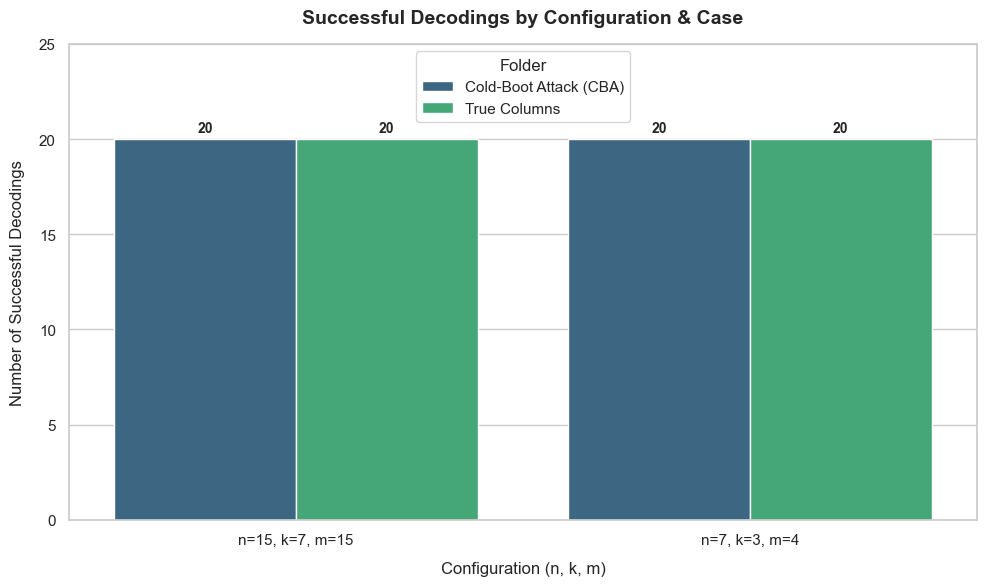

In [4]:
plt.figure(figsize=(10, 6))
ax = sns.barplot(
    data=summary_df, 
    x="Configuration", 
    y="Successful Instances", 
    hue="Folder", 
    palette="viridis"
)
plt.title("Successful Decodings by Configuration & Case", fontsize=14, fontweight="bold", pad=15)
plt.xlabel("Configuration (n, k, m)", fontsize=12, labelpad=10)
plt.ylabel("Number of Successful Decodings", fontsize=12, labelpad=10)
plt.ylim(0, max(summary_df["Successful Instances"].max() * 1.25, 25))

# Add value labels above the bars
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(f'{int(height)}', 
                    (p.get_x() + p.get_width() / 2., height), 
                    ha='center', va='center', 
                    xytext=(0, 8), 
                    textcoords='offset points', 
                    fontsize=10, fontweight='bold')
        
plt.tight_layout()
plt.show()

### 3.2. Execution Time Comparison (All vs. Successful)
Since execution times range from a fraction of a second to several seconds depending on code parameters, we present the mean times on a logarithmic scale for clarity. We show both 'All Instances' and 'Successful Instances' side-by-side.

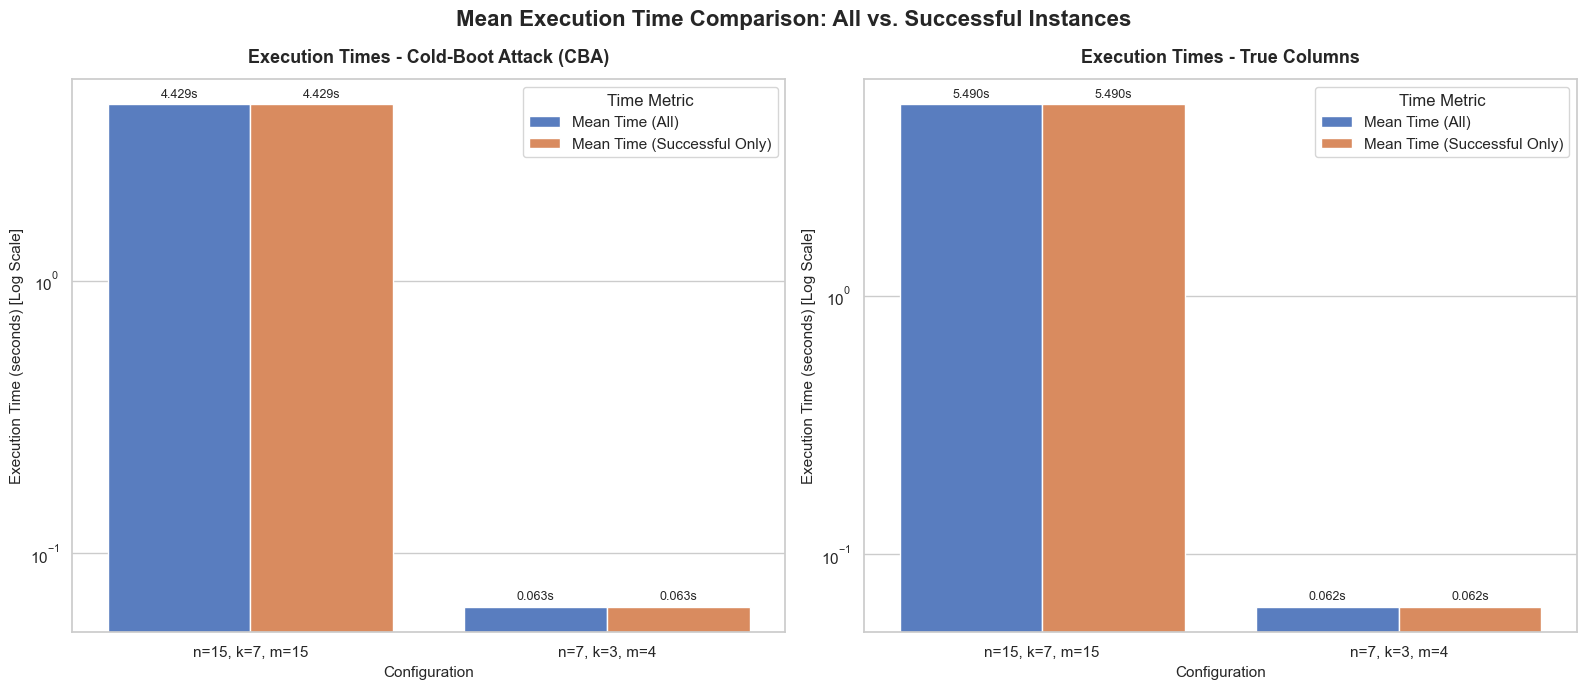

In [5]:
# Pivot/Melt dataframe for plotting
time_melted = pd.melt(
    summary_df, 
    id_vars=["Folder", "Configuration"], 
    value_vars=["Mean Time (All)", "Mean Time (Successful Only)"],
    var_name="Time Metric", 
    value_name="Execution Time (seconds)"
)

fig, axes = plt.subplots(1, 2, figsize=(16, 7), sharey=False)
folders_list = ["Cold-Boot Attack (CBA)", "True Columns"]

for i, folder_name in enumerate(folders_list):
    folder_data = time_melted[time_melted["Folder"] == folder_name]
    ax = sns.barplot(
        data=folder_data,
        x="Configuration",
        y="Execution Time (seconds)",
        hue="Time Metric",
        palette="muted",
        ax=axes[i]
    )
    axes[i].set_title(f"Execution Times - {folder_name}", fontsize=13, fontweight="bold", pad=12)
    axes[i].set_xlabel("Configuration", fontsize=11)
    
    # Log scale to visually handle orders of magnitude difference
    axes[i].set_yscale('log')
    axes[i].set_ylabel("Execution Time (seconds) [Log Scale]", fontsize=11)
    
    # Annotate bars
    for p in ax.patches:
        height = p.get_height()
        if height > 0:
            ax.annotate(f'{height:.3f}s', 
                        (p.get_x() + p.get_width() / 2., height), 
                        ha='center', va='bottom', 
                        xytext=(0, 3), 
                        textcoords='offset points', 
                        fontsize=9)
            
plt.suptitle("Mean Execution Time Comparison: All vs. Successful Instances", fontsize=16, fontweight="bold", y=0.98)
plt.tight_layout()
plt.show()